# 03 — Model Training

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    ConfusionMatrixDisplay, 
    RocCurveDisplay
)

import joblib
import matplotlib.pyplot as plt

In [5]:
MODEL_DATA_PATH = Path("../data/modelling/model_data.csv")

model_data = pd.read_csv(MODEL_DATA_PATH)

print("Loaded model_data:", model_data.shape)
model_data.head()

Loaded model_data: (975, 220)


,home_season_id,home_team_id,home_team_name,home_game_id,home_game_date,home_min,home_fgm,home_fga,home_fg_pct,home_fg3m,...,diff_dreb,diff_reb,diff_ast,diff_stl,diff_blk,diff_tov,diff_pf,diff_pts,diff_plus_minus,diff_video_available
0,22025,1610612737,Atlanta Hawks,22500082,2025-10-22,240,38,90,0.422,10,...,-16.0,-20.0,-11.0,-3.0,2.0,-3.0,-7.0,-20.0,-40.0,0.0
1,22025,1610612737,Atlanta Hawks,22500101,2025-10-25,240,35,85,0.412,16,...,-4.0,-4.0,4.0,-6.0,2.0,4.0,4.0,-17.0,-34.0,0.0
2,22025,1610612737,Atlanta Hawks,22500166,2025-11-04,240,40,72,0.556,13,...,1.0,-7.0,-3.0,2.0,5.0,1.0,-6.0,15.0,30.0,0.0
3,22025,1610612737,Atlanta Hawks,22500030,2025-11-07,240,33,96,0.344,9,...,0.0,6.0,1.0,-3.0,1.0,6.0,-2.0,-12.0,-24.0,0.0
4,22025,1610612737,Atlanta Hawks,22500185,2025-11-08,240,48,93,0.516,16,...,-4.0,-10.0,14.0,5.0,1.0,-9.0,3.0,20.0,40.0,0.0


In [6]:
# Target label
y = model_data["home_win"].astype(int)

# Feature matrix = all numeric columns except label
X = model_data.select_dtypes(include="number").drop(columns=["home_win"], errors="ignore")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (975, 211)
y shape: (975,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((780, 211), (195, 211))

In [8]:
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

log_pred = log_reg.predict(X_test)

print("LogReg Accuracy:", round(accuracy_score(y_test, log_pred), 4))
print(classification_report(y_test, log_pred))

LogReg Accuracy: 0.5385
              precision    recall  f1-score   support

           0       0.49      0.39      0.44        89
           1       0.56      0.66      0.61       106

    accuracy                           0.54       195
   macro avg       0.53      0.53      0.52       195
weighted avg       0.53      0.54      0.53       195



In [9]:
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print(classification_report(y_test, rf_pred))

RF Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        89
           1       1.00      1.00      1.00       106

    accuracy                           1.00       195
   macro avg       1.00      1.00      1.00       195
weighted avg       1.00      1.00      1.00       195



<Figure size 600x500 with 0 Axes>

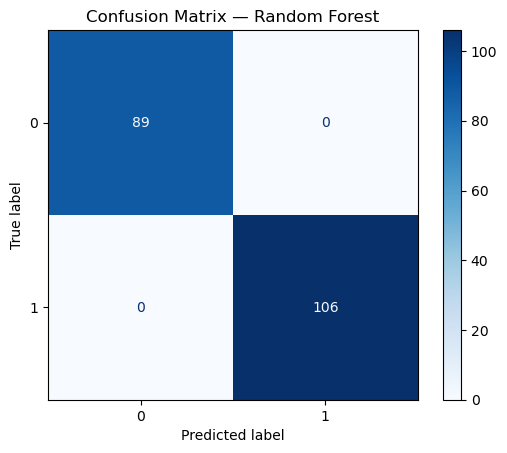

<Figure size 600x500 with 0 Axes>

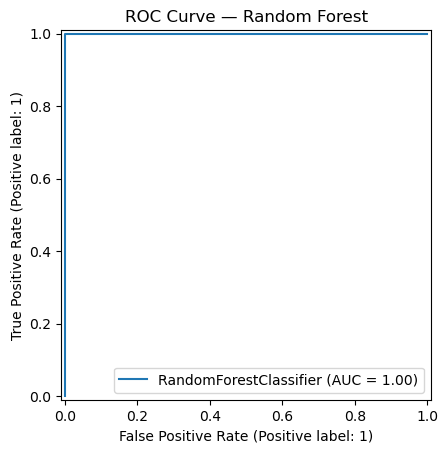

In [10]:
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Random Forest")
plt.show()

plt.figure(figsize=(6,5))
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("ROC Curve — Random Forest")
plt.show()

In [11]:
Path("../models").mkdir(parents=True, exist_ok=True)

joblib.dump(rf, "../models/random_forest.pkl")
joblib.dump(list(X.columns), "../models/model_features.pkl")

print("Saved random_forest.pkl and model_features.pkl")

Saved random_forest.pkl and model_features.pkl
